In [278]:
import numpy as np
import copy,math
import matplotlib.pyplot as plt

##Students marks predictor using feature engineering and polynomial regression.
##This data is a sample data to just train the model
studyhours=np.array([1,2,3,4,5,6,7,2,3,4,5,6])
attendance=np.array([5,6,6,7,7,8,8,5,7,6,8,7])
scholarship=np.array([60,65,70,75,80,85,90,60,72,78,88,82])
study_squared=studyhours**2
##We have used study hours square featured so that instead of a straight line we get a curved feature that increases tht accuract of predictions

x_sample=np.array([studyhours,attendance,scholarship,study_squared]).T

y_sample=np.array([40,45,50,60,65,75,85,42,55,62,80,78])
print(f"X sample data is:{x_sample}")
print(f"Y sample data is:{y_sample}")

x_features=['Study hours','Attendance','Scholarship(in hundreds)','Stdy hours(squared)']

X sample data is:[[ 1  5 60  1]
 [ 2  6 65  4]
 [ 3  6 70  9]
 [ 4  7 75 16]
 [ 5  7 80 25]
 [ 6  8 85 36]
 [ 7  8 90 49]
 [ 2  5 60  4]
 [ 3  7 72  9]
 [ 4  6 78 16]
 [ 5  8 88 25]
 [ 6  7 82 36]]
Y sample data is:[40 45 50 60 65 75 85 42 55 62 80 78]


In [279]:
def old_predict(w,x,b):
    m=x.shape[0]
    p=0
    for i in range(m):
        p_i=w[i]*x[i]
        p=p+p_i
    p=p+b
##Above is an old prediction system, while below is a new vectorised form.


def predict(w,x,b):
    p=np.dot(w,x) + b   
    return p
        
        

In [280]:
w_intial=np.zeros(4)
b_intial=0.0
print(f"Intial values of W is{w_intial} and Intial values of B is {b_intial}")

Intial values of W is[0. 0. 0. 0.] and Intial values of B is 0.0


In [281]:
def cost_fn(x,y,w,b):
    n=x.shape[0]
    cost=0
    for i in range(n):
        fn=predict(w,x[i],b)
        cost_i=(fn - y[i])**2
        cost=cost+cost_i
    cost=cost/(2*n)
    return cost
        

In [282]:
def gradient(x,y,w,b):
    m=x.shape[0]
    n=x.shape[1]
    dw=np.zeros((n,))
    db=0.0
    for i in range(m):
        error=predict(w,x[i],b) - y[i]
        for j in range(n):
            dw[j]=dw[j]+ error*x[i,j]
        db=db+error
    dw=dw/m
    db=db/m
    return dw,db
        

In [283]:
def gradient_descent(x,y,w,b,num_iters,cost_fn,alpha,gradient):
    history=[]
    for i in range(num_iters):
        dw,db=gradient(x,y,w,b)
 
        w= w - alpha*dw
        b= b - alpha*db

        history.append( cost_fn(x, y, w, b))

        if i%100==0:
            print(f"Iteration:{i}   Cost:{history[-1]}")
    return w,b,history
    

In [284]:
iterations=1000
alpha=6e-7

w_final,b_final,history_final=gradient_descent(x_sample,y_sample,w_intial,b_intial,iterations,cost_fn,alpha,gradient)

m=x_sample.shape[0]
for i in range(m):
    print(f"Prediction: {predict(w_final,x_sample[i],b_final)}, Actual value: {y_sample[i]}")

def plot_cost(history):

    import matplotlib.pyplot as plt

    plt.plot(history)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost vs Iterations")
    plt.show()




Iteration:0   Cost:1981.5889281224318
Iteration:100   Cost:936.3368173706922
Iteration:200   Cost:445.489035401323
Iteration:300   Cost:214.95332255280115
Iteration:400   Cost:106.64374101856987
Iteration:500   Cost:55.72441545876499
Iteration:600   Cost:31.75276699104875
Iteration:700   Cost:20.434992763062894
Iteration:800   Cost:15.059667872441976
Iteration:900   Cost:12.475541746592464
Prediction: 44.81545938607895, Actual value: 40
Prediction: 49.309408867102086, Actual value: 45
Prediction: 54.20533598877324, Actual value: 50
Prediction: 59.63404907080937, Actual value: 60
Prediction: 65.46473979349351, Actual value: 65
Prediction: 71.82821647654264, Actual value: 75
Prediction: 78.59367080023976, Actual value: 85
Prediction: 45.56054728701644, Actual value: 42
Prediction: 55.74412311672259, Actual value: 55
Prediction: 61.77871936308719, Actual value: 62
Prediction: 71.42367582571546, Actual value: 80
Prediction: 69.55273786454785, Actual value: 78


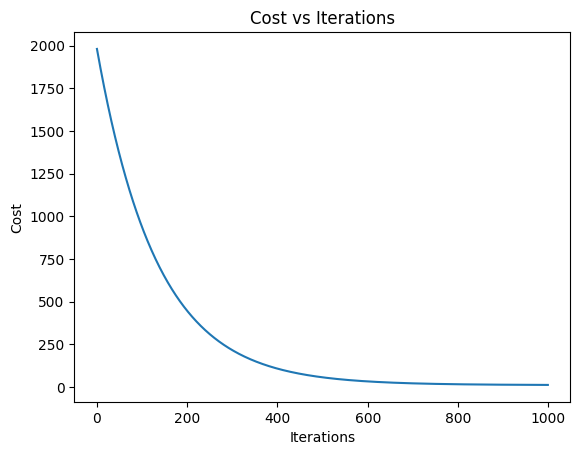

In [269]:
plot_cost(history_final)
##This is to check for ther best alpha value.

In [285]:
#Now to make this program more fast and better we use Z-score normalization.

def zscore_normalization(x):
    mu=np.mean(x,axis=0)
    sigma=np.std(x,axis=0)

    x_final=(x-mu)/sigma

    return(x_final,mu,sigma)

    
    


Iteration:0   Cost:1951.2010946577766
Iteration:100   Cost:251.38792385121675
Iteration:200   Cost:36.741868849098374
Iteration:300   Cost:7.902061985821606
Iteration:400   Cost:3.960372280276475
Iteration:500   Cost:3.363175020914554
Iteration:600   Cost:3.2213577816804317
Iteration:700   Cost:3.146783781621363
Iteration:800   Cost:3.086618107662604
Iteration:900   Cost:3.033109430032123


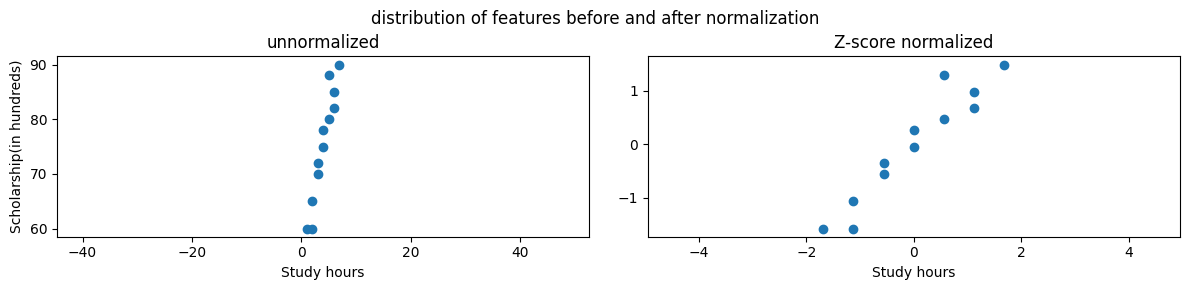

In [286]:
##Finding x values after normalization and using it to find w_norm and b_norm.
##We also get another alpha value for normalized data.
x_norm,x_mu,x_sigma=zscore_normalization(x_sample)
alpha_norm=1e-2
w_norm, b_norm, hist = gradient_descent(x_norm,y_sample,w_intial,b_intial,iterations,cost_fn,alpha_norm,gradient)

fig,ax=plt.subplots(1, 2, figsize=(12, 3))
ax[0].scatter(x_sample[:,0], x_sample[:,2])
ax[0].set_xlabel(x_features[0]); ax[0].set_ylabel(x_features[2]);
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(x_norm[:,0], x_norm[:,2])
ax[1].set_xlabel(x_features[0]); ax[0].set_ylabel(x_features[2]);
ax[1].set_title(r"Z-score normalized")
ax[1].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before and after normalization")
plt.show()

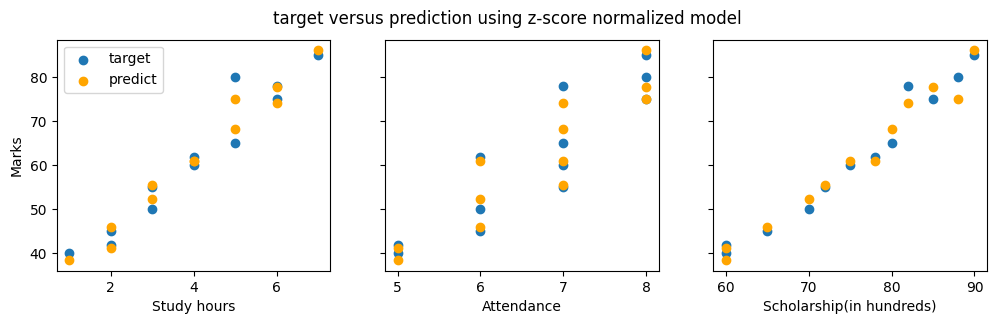

In [287]:
m = x_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = predict(w_norm, x_norm[i], b_norm)

    # plot predictions and targets versus original features    
fig,ax=plt.subplots(1,3,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_sample[:,i],y_sample, label = 'target')
    ax[i].set_xlabel(x_features[i])
    ax[i].scatter(x_sample[:,i],yp,color="orange", label = 'predict')
ax[0].set_ylabel("Marks"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

In [288]:
# Now we will make it input some stuff and make it calculate data according to the model.
print("Study hours:")
study_hr=int(input())
print("Attendance:")
att=int(input())
print("Scholarship:")
sch=int(input())
study_sqr=study_hr**2

data=[study_hr,att,sch,study_sqr]
data_norm=(data-x_mu)/x_sigma
print(data_norm)

data_final_predict=predict(data_norm,w_norm,b_norm)
print(data_final_predict)

print(f"The predicted marks for student with {study_hr} study hours,{att} attendance,{sch} scholarship is: {data_final_predict}")

Study hours:


 1


Attendance:


 5


Scholarship:


 60


[-1.68585446 -1.62221421 -1.56875456 -1.24826437]
38.4601591206209
The predicted marks for student with 1 study hours,5 attendance,60 scholarship is: 38.4601591206209
